## Import thư viện và đọc dataset

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("banknote_authentication.csv", header=None)
df.columns = ["variance", "skewness", "curtosis", "entropy", "class"]
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## 1. Tách Feature và Target

In [2]:
X = df.drop("class", axis=1)
y = df["class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1372, 4)
Target shape: (1372,)


## 2. Chia Train/Test (70/30)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (960, 4)
Test size: (412, 4)


## 3. Chuẩn hóa dữ liệu (StandardScaler)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit trên train
scaler.fit(X_train)

# transform
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[-0.34250428, -0.07318046, -0.66029833,  0.03581159],
       [ 0.02233035,  0.2550447 , -1.36872002, -1.36434276],
       [ 0.22934938,  1.10093691, -0.65459638, -0.21668155],
       ...,
       [-2.6060329 ,  1.25716945, -0.29446746, -1.60253931],
       [-1.35454634,  0.14180187, -0.29545381,  0.08484218],
       [-1.31874359, -1.53564138,  2.29807266,  0.30133958]],
      shape=(960, 4))

## 4. Kiểm tra mean và std sau khi scale

In [5]:
print("Mean:", X_train_scaled.mean(axis=0))
print("Std:", X_train_scaled.std(axis=0))

Mean: [ 4.44089210e-17  0.00000000e+00 -1.48029737e-17  2.59052039e-17]
Std: [1. 1. 1. 1.]


## 5. Kiểm tra Missing Values

In [6]:
df.isnull().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

## 6. Encoding dữ liệu

In [7]:
df.dtypes

variance    float64
skewness    float64
curtosis    float64
entropy     float64
class         int64
dtype: object

## 7. Kiểm tra Outliers

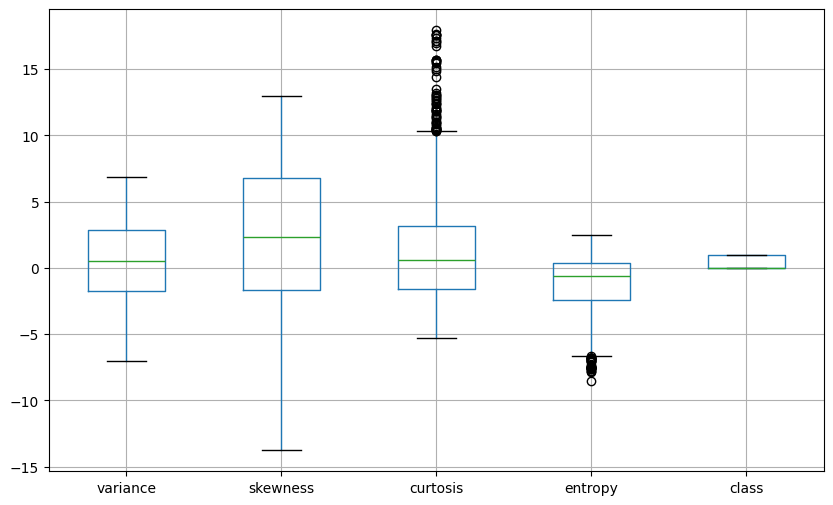

In [8]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(10,6))
plt.show()

## 8. Chuẩn bị dữ liệu 

In [9]:
import joblib

joblib.dump(X_train_scaled, "X_train.pkl")
joblib.dump(X_test_scaled, "X_test.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']